# Import and Model Loading:

In [20]:
import sys
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from xray.interpretability import *

In [21]:
from xray.evaluation import (
    predict_target_logit,
    top_k_deletion_curve,
    random_deletion_curve,
    evaluate_logit_faithfulness
)

print("evaluation.py imported successfully")

evaluation.py imported successfully


In [22]:
#IMPORTS:

import torch
import matplotlib.pyplot as plt

from transformers import (
    DistilBertForSequenceClassification,
    DistilBertTokenizer
)

from xray.interpretability import DistilBertInterpreter

# LOAD THE HUGGINGFACE MODEL:

# Use GPU if available
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

model = DistilBertForSequenceClassification.from_pretrained(
    "JDsouza1/distilbert-imdb-sentiment"
).to(device)

tokenizer = DistilBertTokenizer.from_pretrained(
    "JDsouza1/distilbert-imdb-sentiment"
)

print("Model loaded!")

Device: cpu


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 952.69it/s]


Model loaded!


In [23]:
interpreter = DistilBertInterpreter(
    model=model,
    tokenizer=tokenizer,
    device=device
)

# Testing with one sentence:

In [24]:
test_text = "This was not a bad movie at all"

(
    tokens,
    token_attributions,
    delta,
    input_output,
    baseline_output,
    total_attribution,
    completeness_error
) = interpreter.attribute(test_text)

In [25]:
with torch.no_grad():
    encoding = tokenizer(
        test_text,
        return_tensors="pt",
        truncation=True,
        padding=False
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    target_label = torch.argmax(
        outputs.logits,
        dim=1
    ).item()

print("Target label:", target_label)
print("Target logit:", input_output.item())

Target label: 1
Target logit: 0.7795644998550415


Aggregate token attributions:

In [26]:
words, word_scores = interpreter.aggregate_tokens(
    tokens,
    token_attributions
)

print("Word-level attributions:")

for word, score in zip(words, word_scores):
    print(f"{word:15} {float(score):+.4f}")

Word-level attributions:
this            +0.2466
was             +0.2090
not             +0.5315
a               +0.5419
bad             -0.4694
movie           -0.5103
at              +0.1927
all             -0.0304


# Attribution-guided deletion curve:

In [33]:
from xray.evaluation import top_k_deletion_curve

top_k_curve = top_k_deletion_curve(
    model=model,
    tokenizer=tokenizer,
    text=test_text,
    tokens=tokens,
    scores=word_scores,
    target_label=target_label,
    device=device
)

In [28]:
# Inspect:
print("Fractions:")
print(top_k_curve["fractions"])

print("\nTarget logits:")
print(top_k_curve["logits"])

Fractions:
[0.0, 0.125, 0.25, 0.375, 0.5, 0.625, 0.75, 0.875, 1.0]

Target logits:
[0.653679370880127, 0.2926931083202362, -2.66717267036438, -2.246964693069458, -1.1101876497268677, -0.7327213883399963, -0.44897225499153137, -0.010651255957782269, -0.030771732330322266]


# Random Baseline:

In [29]:
from xray.evaluation import random_deletion_curve

random_curve = random_deletion_curve(
    model=model,
    tokenizer=tokenizer,
    text=test_text,
    tokens=tokens,
    target_label=target_label,
    device=device,
    seed=42
)

In [30]:
# Inspect:
print("Fractions:")
print(random_curve["fractions"])

print("\nRandom deletion logits:")
print(random_curve["logits"])

Fractions:
[0.0, 0.125, 0.25, 0.375, 0.5, 0.625, 0.75, 0.875, 1.0]

Random deletion logits:
[0.653679370880127, 0.2926931083202362, -2.1621296405792236, -1.5901036262512207, 0.016108114272356033, -0.5189729928970337, 0.12416292726993561, -0.07643508911132812, -0.030771732330322266]


# Compare Attribution-guided deletion curve vs Random Baseline:
top-k vs random

In [37]:
import importlib
import xray.evaluation as evaluation

evaluation = importlib.reload(evaluation)

print("evaluation.py reloaded")

evaluation.py reloaded


In [38]:
print(inspect.getsource(evaluation.evaluate_logit_faithfulness))

def evaluate_logit_faithfulness(
    top_k_curve,
    random_curve
):
    """
    Compare attribution-guided deletion against random deletion.

    Measures the area under the cumulative target-logit drop curve.

    A larger AUC means the target logit drops more rapidly
    as important features are deleted.
    """

    top_k_logits = np.asarray(
        top_k_curve["logits"],
        dtype=float
    )

    random_logits = np.asarray(
        random_curve["logits"],
        dtype=float
    )

    fractions = np.asarray(
        top_k_curve["fractions"],
        dtype=float
    )

    original_logit = float(
        top_k_curve["original_logit"]
    )

    # Convert logits into cumulative drops.
    top_k_drops = (
        original_logit - top_k_logits
    )

    random_drops = (
        original_logit - random_logits
    )

    # Area under cumulative-drop curves.
    top_k_auc = np.trapezoid(
        top_k_drops,
        fractions
    )

    random_auc = np.trapezoid(
        random

In [39]:
from xray.evaluation import evaluate_logit_faithfulness

faithfulness = evaluation.evaluate_logit_faithfulness(
    top_k_curve,
    random_curve
)

print("\nFAITHFULNESS EVALUATION")
print("-" * 40)

for key, value in faithfulness.items():
    print(f"{key}: {value}")


FAITHFULNESS EVALUATION
----------------------------------------
original_logit: 0.653679370880127
top_k_final_logit: -0.030771732330322266
random_final_logit: -0.030771732330322266
top_k_final_drop: 0.6844511032104492
random_final_drop: 0.6844511032104492
top_k_drop_auc: 1.4802447439869866
random_drop_auc: 1.104082293342799
top_k_auc_higher: True


The final drop is identical because both methods eventually delete all words.
The meaningful comparison is:

Top-k deletion AUC       1.4802
Random deletion AUC      1.1041

The attribution-guided deletion produces a larger cumulative logit-drop area, meaning the target logit decreased more rapidly over the deletion process for this example.

So this particular example provides evidence that the attribution ranking is capturing features influential to the target prediction.

But don't conclude that the attribution method is generally faithful yet. We need multiple examples and ideally repeated random baselines.

# Visualizing curves:

We're looking for whether the attribution-guided curve generally rises faster/earlier than the random curve.
If that behavior is observed, it visually supports the AUC result.


**Raw logit deletion curve:**

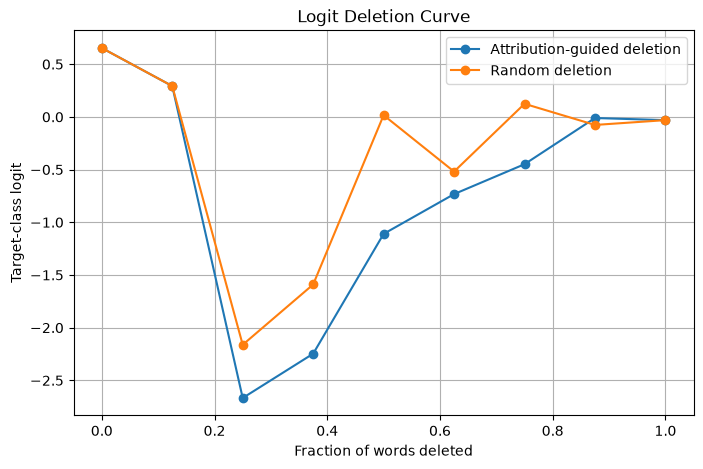

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    top_k_curve["fractions"],
    top_k_curve["logits"],
    marker="o",
    label="Attribution-guided deletion"
)

plt.plot(
    random_curve["fractions"],
    random_curve["logits"],
    marker="o",
    label="Random deletion"
)

plt.xlabel("Fraction of words deleted")
plt.ylabel("Target-class logit")
plt.title("Logit Deletion Curve")

plt.legend()
plt.grid(True)

plt.show()

**Cumulative drop:**

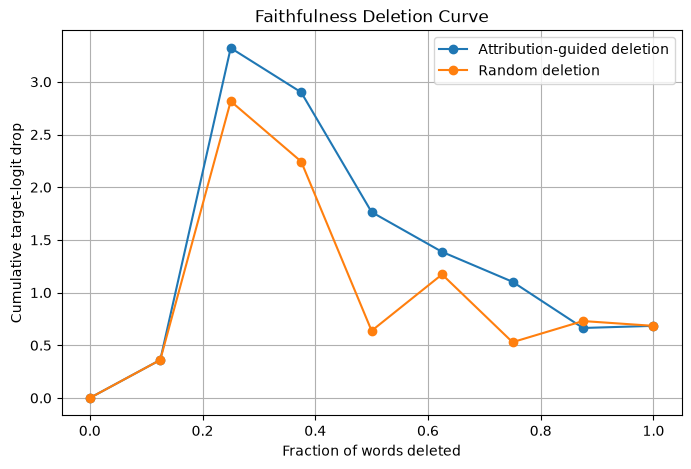

In [41]:
original_logit = top_k_curve["original_logit"]

top_k_drop = [
    original_logit - logit
    for logit in top_k_curve["logits"]
]

random_drop = [
    original_logit - logit
    for logit in random_curve["logits"]
]

plt.figure(figsize=(8, 5))

plt.plot(
    top_k_curve["fractions"],
    top_k_drop,
    marker="o",
    label="Attribution-guided deletion"
)

plt.plot(
    random_curve["fractions"],
    random_drop,
    marker="o",
    label="Random deletion"
)

plt.xlabel("Fraction of words deleted")
plt.ylabel("Cumulative target-logit drop")
plt.title("Faithfulness Deletion Curve")

plt.legend()
plt.grid(True)

plt.show()

In [43]:
print("top_k_curve logits")
print(top_k_curve["logits"])
print("random_curve logits")
print(random_curve["logits"])

top_k_curve logits
[0.653679370880127, 0.2926931083202362, -2.66717267036438, -2.246964693069458, -1.1101876497268677, -0.7327213883399963, -0.44897225499153137, -0.010651255957782269, -0.030771732330322266]
random_curve logits
[0.653679370880127, 0.2926931083202362, -2.1621296405792236, -1.5901036262512207, 0.016108114272356033, -0.5189729928970337, 0.12416292726993561, -0.07643508911132812, -0.030771732330322266]


The important observation is that both curves behave non-monotonically. That's not necessarily a bug.
Deleting a word can cause the model's target logit to:
decrease,
increase,
cross zero,
decrease again.
For a nonlinear Transformer, that's completely possible.